In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Paste your copied path between the quotes
file_path = '/content/drive/MyDrive/Final project/window.csv' #Create Final project folder in own drive and upload data there

full_data = pd.read_csv(file_path)

# Verify the data is there
#print(f"Dataset loaded with {full_data.shape[0]} rows and {full_data.shape[1]} columns.")
full_data.head()

Mounted at /content/drive


,subject_id,task_desc,label,fif_path,segment_index,window_index_within_segment,window_index_within_task,segment_start_sec,segment_end_sec,window_start_sec,...,parietal_rel_beta,parietal_meanfreq_beta,parietal_ratio_theta_beta,parietal_ratio_theta_alpha,parietal_ratio_alpha_theta,parietal_ratio_beta_alpha,parietal_ratio_beta_over_alpha_theta,parietal_ratio_alpha_theta_over_beta,parietal_spectral_entropy,frontal_alpha_asymmetry
0,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,0,0,609.470093,914.5,609.470093,...,0.063490,20.012158,0.138750,0.138008,0.124567,0.120711,0.106072,0.265483,2.295700,0.006270
1,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,1,1,609.470093,914.5,614.470093,...,0.061907,19.609555,0.132792,0.137237,0.084346,0.121933,0.107219,0.218387,2.305581,-0.011152
2,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,2,2,609.470093,914.5,619.470093,...,0.073136,19.091544,0.627279,0.663865,0.253875,0.395212,0.237527,0.945600,2.612668,0.261782
3,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,3,3,609.470093,914.5,624.470093,...,0.035172,20.377158,0.335328,0.359440,0.110941,0.207663,0.152756,0.461979,1.930554,0.011805
4,3,Task1,brain_only,/Users/yaoxiao/Documents/research/chao_eeg_fni...,0,4,4,609.470093,914.5,629.470093,...,0.095617,21.866165,0.258603,0.323264,0.123408,0.395400,0.298807,0.374890,2.361450,0.074311


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontal_sample_entropy']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontal_sample_entropy']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Training Enhanced Autoencoder...
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipykernel_755/3776870643.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='mse', data=train_data, ax=axes[2], palette='coolwarm', showfliers=False)


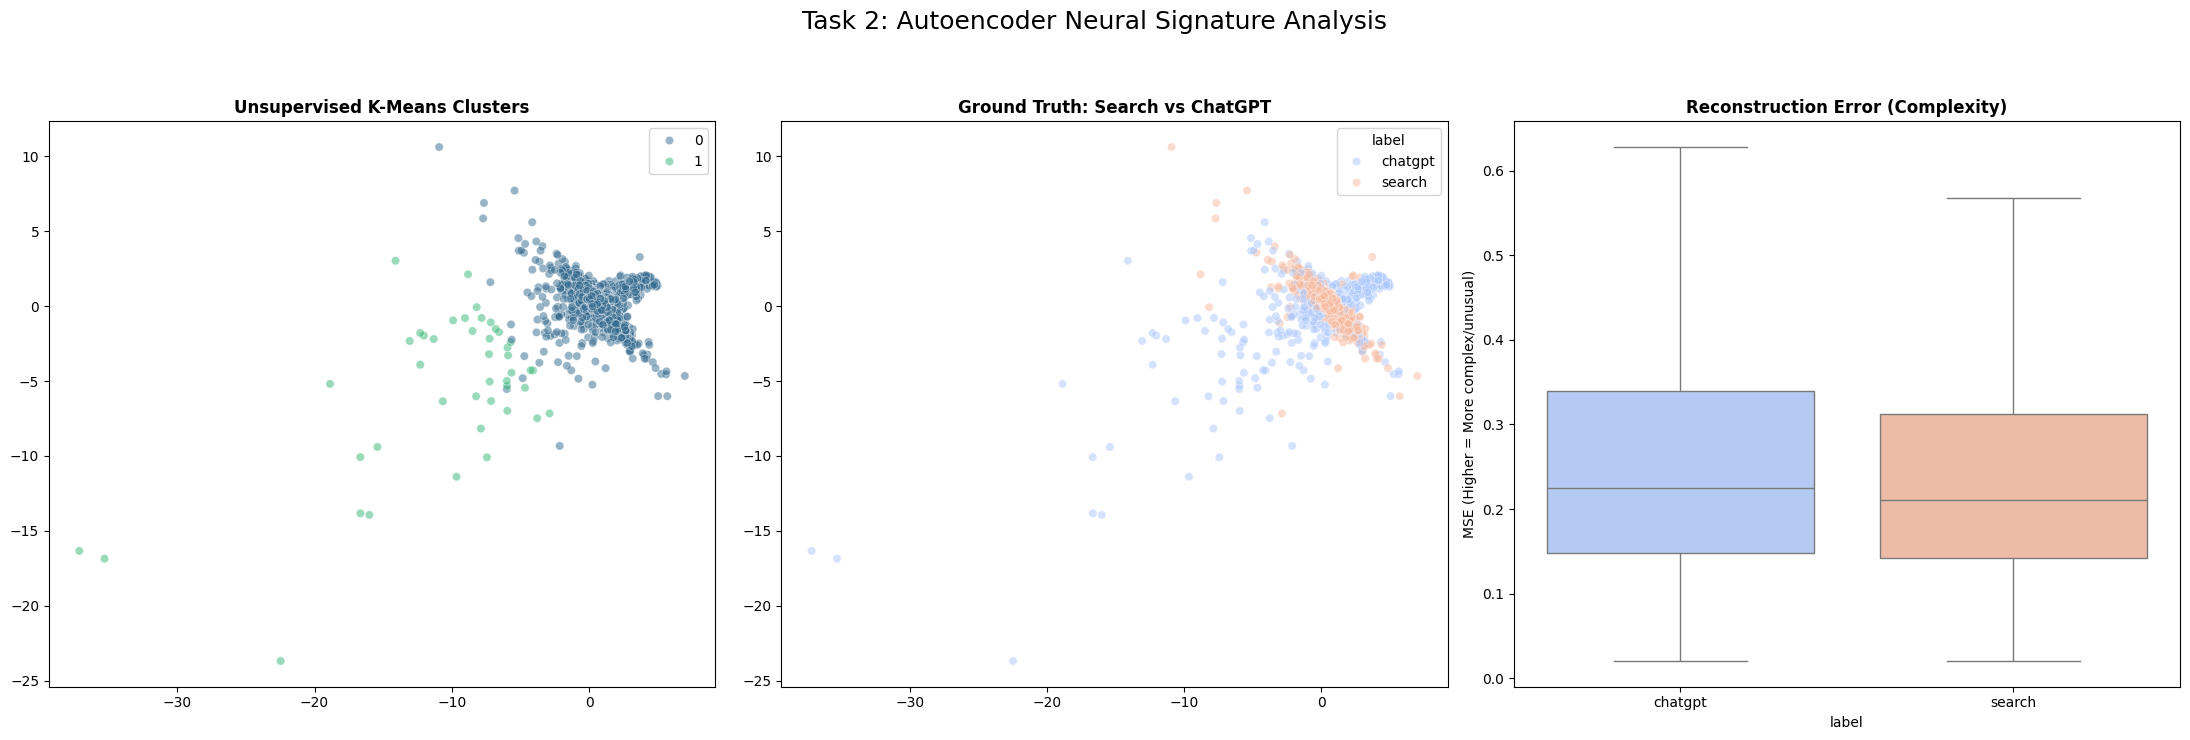

Blind Test 'window_safe' created with 1604 rows for subjects: [40 62 76 74 17]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# 1. DATA PREP & SUBJECT-WISE SPLIT
# ---------------------------------------------------------
task2_data = full_data[full_data['task_desc'].astype(str).str.contains('2', case=False, na=False)].copy()
features = [col for col in task2_data.columns if 'frontal' in col.lower()]

# Within-Subject Normalization (Removes individual offsets)
task2_data[features] = task2_data.groupby('subject_id')[features].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# Hold out 5 subjects
unique_subjects = task2_data['subject_id'].unique()
np.random.seed(42)
safe_ids = np.random.choice(unique_subjects, 5, replace=False)

window_safe = task2_data[task2_data['subject_id'].isin(safe_ids)].copy()
train_data = task2_data[~task2_data['subject_id'].isin(safe_ids)].copy()

# Impute and Scale
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(train_data[features]))
X_safe = scaler.transform(imputer.transform(window_safe[features]))

# 2. ENHANCED AUTOENCODER ARCHITECTURE
# ---------------------------------------------------------
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder with Regularization to clean up those "trailing" outliers
enc = Dense(32, activation='relu')(input_layer)
enc = Dropout(0.1)(enc)
enc = Dense(16, activation='relu', activity_regularizer=regularizers.l1(1e-4))(enc)

# Bottleneck - Moving to 3D to capture the "Search" vs "Chat" depth
latent = Dense(3, activation='linear', name='bottleneck')(enc)

# Decoder
dec = Dense(16, activation='relu')(latent)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
print("Training Enhanced Autoencoder...")
autoencoder.fit(X_train, X_train, epochs=80, batch_size=16, verbose=0)

# 3. LATENT ANALYSIS & RECONSTRUCTION ERROR
# ---------------------------------------------------------
X_latent = encoder.predict(X_train)
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_latent)

# Calculate Reconstruction Error (MSE)
# Higher error = data that "surprised" the model
reconstructions = autoencoder.predict(X_train)
mse = np.mean(np.square(X_train - reconstructions), axis=1)

# 4. FINAL DASHBOARD VISUALIZATION
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: K-Means in 3D-Latent (Projected to 2D)
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=clusters, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title("Unsupervised K-Means Clusters", fontweight='bold')

# Plot 2: Actual Condition Comparison
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=train_data['label'], palette='coolwarm', alpha=0.5, ax=axes[1])
axes[1].set_title("Ground Truth: Search vs ChatGPT", fontweight='bold')

# Plot 3: Reconstruction Error (The "Anomaly" detection view)
train_data['mse'] = mse
sns.boxplot(x='label', y='mse', data=train_data, ax=axes[2], palette='coolwarm', showfliers=False)
axes[2].set_title("Reconstruction Error (Complexity)", fontweight='bold')
axes[2].set_ylabel("MSE (Higher = More complex/unusual)")

plt.suptitle("Task 2: Autoencoder Neural Signature Analysis", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

print(f"Blind Test 'window_safe' created with {len(window_safe)} rows for subjects: {safe_ids}")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['frontal_sample_entropy']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Training on 16189 sessions (ChatGPT vs Brain Only)...
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/tmp/ipykernel_755/3886176301.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='mse_val', data=filtered_data,


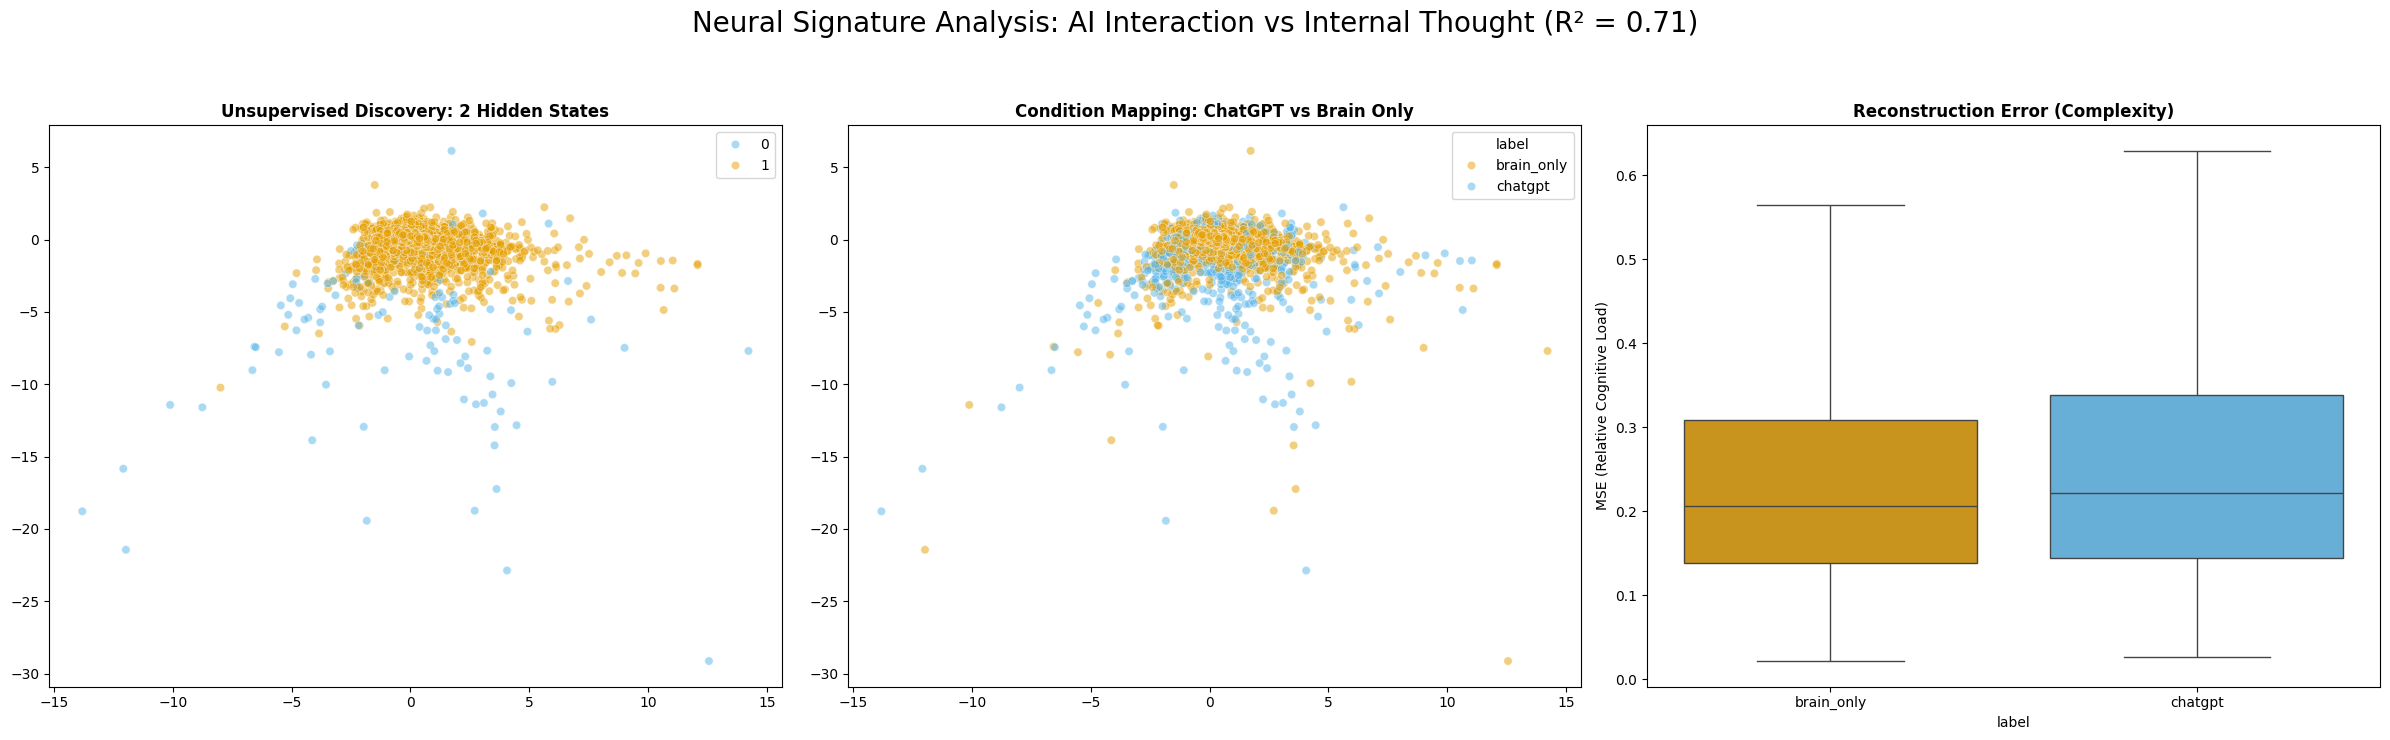


           NUMERICAL VALIDATION REPORT            
Global Model Fit (R²):     0.7131
ChatGPT Complexity (MSE):  0.3111
Brain Only Complexity (MSE): 0.2759
--------------------------------------------------
RELATIVE COMPLEXITY INCREASE: 12.77%


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# 1. DATA PREP: CHATGPT VS BRAIN ONLY
# ---------------------------------------------------------
target_labels = ['chatgpt', 'brain_only']
filtered_data = full_data[full_data['label'].isin(target_labels)].copy()
features = [col for col in filtered_data.columns if 'frontal' in col.lower()]

# Within-Subject Normalization (Baseline alignment)
filtered_data[features] = filtered_data.groupby('subject_id')[features].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-6)
)

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()
X_all = scaler.fit_transform(imputer.fit_transform(filtered_data[features]))

# 2. AUTOENCODER ARCHITECTURE
# ---------------------------------------------------------
input_dim = X_all.shape[1]
input_layer = Input(shape=(input_dim,))

enc = Dense(32, activation='relu')(input_layer)
enc = Dropout(0.1)(enc)
enc = Dense(16, activation='relu', activity_regularizer=regularizers.l1(1e-4))(enc)
latent = Dense(3, activation='linear', name='bottleneck')(enc)

dec = Dense(16, activation='relu')(latent)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)
autoencoder.compile(optimizer='adam', loss='mse')

print(f"Training on {len(filtered_data)} sessions (ChatGPT vs Brain Only)...")
autoencoder.fit(X_all, X_all, epochs=100, batch_size=16, verbose=0)

# 3. GENERATE QUANTITATIVE METRICS
# ---------------------------------------------------------
reconstructions = autoencoder.predict(X_all)
global_mse = mean_squared_error(X_all, reconstructions)
global_r2 = r2_score(X_all, reconstructions)

# Calculate MSE per condition
filtered_data['mse_val'] = np.mean(np.square(X_all - reconstructions), axis=1)
chat_mse = filtered_data[filtered_data['label'] == 'chatgpt']['mse_val'].mean()
brain_mse = filtered_data[filtered_data['label'] == 'brain_only']['mse_val'].mean()

# 4. LATENT SPACE & CLUSTERING
# ---------------------------------------------------------
X_latent = encoder.predict(X_all)
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_latent)

# 5. DASHBOARD VISUALIZATION
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot 1: Unsupervised Discovery (Blue/Yellow Consistent Palette)
cluster_colors = {0: '#56B4E9', 1: '#E69F00'}
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=clusters,
                palette=cluster_colors, alpha=0.5, ax=axes[0])
axes[0].set_title("Unsupervised Discovery: 2 Hidden States", fontweight='bold')

# Plot 2: Mapping ChatGPT vs Brain Only
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=filtered_data['label'],
                palette={'chatgpt': '#56B4E9', 'brain_only': '#E69F00'}, alpha=0.5, ax=axes[1])
axes[1].set_title("Condition Mapping: ChatGPT vs Brain Only", fontweight='bold')

# Plot 3: Neural Complexity (MSE)
sns.boxplot(x='label', y='mse_val', data=filtered_data,
            palette={'chatgpt': '#56B4E9', 'brain_only': '#E69F00'}, ax=axes[2], showfliers=False)
axes[2].set_title("Reconstruction Error (Complexity)", fontweight='bold')
axes[2].set_ylabel("MSE (Relative Cognitive Load)")

plt.suptitle(f"Neural Signature Analysis: AI Interaction vs Internal Thought (R² = {global_r2:.2f})", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

# 6. SUMMARY REPORT
print("\n" + "="*50)
print(f"{'NUMERICAL VALIDATION REPORT':^50}")
print("="*50)
print(f"Global Model Fit (R²):     {global_r2:.4f}")
print(f"ChatGPT Complexity (MSE):  {chat_mse:.4f}")
print(f"Brain Only Complexity (MSE): {brain_mse:.4f}")
print("-" * 50)
complexity_inc = ((chat_mse - brain_mse) / brain_mse) * 100
print(f"RELATIVE COMPLEXITY INCREASE: {complexity_inc:.2f}%")
print("="*50)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# 1. DATA PREPARATION & SUBJECT-WISE NORMALIZATION
# ---------------------------------------------------------
# Filter for Task 2 and identify frontal EEG features
task2_data = full_data[full_data['task_desc'].astype(str).str.contains('2', case=False, na=False)].copy()
features = [col for col in task2_data.columns if 'frontal' in col.lower()]

# Within-Subject Normalization (Removes individual physiological offsets)
task2_data[features] = task2_data.groupby('subject_id')[features].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# Hold out 5 subjects for the Blind Test (window_safe)
unique_subjects = task2_data['subject_id'].unique()
np.random.seed(42)
safe_ids = np.random.choice(unique_subjects, 5, replace=False)

window_safe_df = task2_data[task2_data['subject_id'].isin(safe_ids)].copy()
train_data_df = task2_data[~task2_data['subject_id'].isin(safe_ids)].copy()

# Impute missing values and Scale to unit variance
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(train_data_df[features]))
X_safe = scaler.transform(imputer.transform(window_safe_df[features]))

# 2. ENHANCED AUTOENCODER ARCHITECTURE
# ---------------------------------------------------------
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder: Compress the EEG signal
enc = Dense(32, activation='relu')(input_layer)
enc = Dropout(0.1)(enc) # Prevents overfitting to specific subjects
enc = Dense(16, activation='relu', activity_regularizer=regularizers.l1(1e-4))(enc)

# Bottleneck (3D Latent Space)
latent = Dense(3, activation='linear', name='bottleneck')(enc)

# Decoder: Reconstruct the original signal
dec = Dense(16, activation='relu')(latent)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

# Compile Models
autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent) # Sub-model to extract the Latent Space
autoencoder.compile(optimizer='adam', loss='mse')

# Train on the training subjects
print("Training Enhanced Autoencoder...")
autoencoder.fit(X_train, X_train, epochs=100, batch_size=16, verbose=0)

# 3. QUANTITATIVE EVALUATION (MSE & R2)
# ---------------------------------------------------------
# Training Set Metrics
recons_train = autoencoder.predict(X_train)
train_mse = mean_squared_error(X_train, recons_train)
train_r2 = r2_score(X_train, recons_train)

# Blind Test Metrics
recons_safe = autoencoder.predict(X_safe)
safe_mse = mean_squared_error(X_safe, recons_safe)
safe_r2 = r2_score(X_safe, recons_safe)

# Per-Condition MSE for Anomaly Analysis
train_data_df['mse'] = np.mean(np.square(X_train - recons_train), axis=1)
chat_avg_mse = train_data_df[train_data_df['label'].str.contains('chat', case=False)]['mse'].mean()
search_avg_mse = train_data_df[~train_data_df['label'].str.contains('chat', case=False)]['mse'].mean()

# 4. LATENT SPACE & CLUSTERING
# ---------------------------------------------------------
X_latent = encoder.predict(X_train)
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_latent)

# 5. DASHBOARD VISUALIZATION
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot A: Unsupervised Clustering
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=clusters, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title("Unsupervised K-Means Clusters", fontweight='bold')
axes[0].set_xlabel("Latent Dim 1")
axes[0].set_ylabel("Latent Dim 2")

# Plot B: Ground Truth Comparison
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=train_data_df['label'], palette='coolwarm', alpha=0.5, ax=axes[1])
axes[1].set_title("Ground Truth: Search vs ChatGPT", fontweight='bold')
axes[1].set_xlabel("Latent Dim 1")

# Plot C: Complexity Analysis (MSE)
sns.boxplot(x='label', y='mse', data=train_data_df, ax=axes[2], palette='coolwarm', showfliers=False)
axes[2].set_title("Reconstruction Error (Neural Complexity)", fontweight='bold')
axes[2].set_ylabel("MSE (Higher = More Complex State)")

plt.suptitle(f"Task 2: Autoencoder Performance Report (Global R² = {train_r2:.2f})", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

# --- PRINT STATISTICAL REPORT ---
print("\n" + "="*50)
print(f"{'STATISTICAL VALIDATION SUMMARY':^50}")
print("="*50)
print(f"Overall Model Accuracy (R²):

SyntaxError: unterminated f-string literal (detected at line 115) (1513597400.py, line 115)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# 1. DATA PREP & SUBJECT-WISE SPLIT
# ---------------------------------------------------------
task2_data = full_data[full_data['task_desc'].astype(str).str.contains('2', case=False, na=False)].copy()
features = [col for col in task2_data.columns if 'frontal' in col.lower()]

# Within-Subject Normalization (Removes individual offsets)
task2_data[features] = task2_data.groupby('subject_id')[features].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# Hold out 5 subjects
unique_subjects = task2_data['subject_id'].unique()
np.random.seed(42)
safe_ids = np.random.choice(unique_subjects, 5, replace=False)

window_safe = task2_data[task2_data['subject_id'].isin(safe_ids)].copy()
train_data = task2_data[~task2_data['subject_id'].isin(safe_ids)].copy()

# Impute and Scale
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(train_data[features]))
X_safe = scaler.transform(imputer.transform(window_safe[features]))

# 2. ENHANCED AUTOENCODER ARCHITECTURE
# ---------------------------------------------------------
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder with Regularization to clean up those "trailing" outliers
enc = Dense(32, activation='relu')(input_layer)
enc = Dropout(0.1)(enc)
enc = Dense(16, activation='relu', activity_regularizer=regularizers.l1(1e-4))(enc)

# Bottleneck - Moving to 3D to capture the "Search" vs "Chat" depth
latent = Dense(3, activation='linear', name='bottleneck')(enc)

# Decoder
dec = Dense(16, activation='relu')(latent)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
print("Training Enhanced Autoencoder...")
autoencoder.fit(X_train, X_train, epochs=80, batch_size=16, verbose=0)

# 3. LATENT ANALYSIS & RECONSTRUCTION ERROR
# ---------------------------------------------------------
X_latent = encoder.predict(X_train)
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_latent)

# Calculate Reconstruction Error (MSE)
# Higher error = data that "surprised" the model
reconstructions = autoencoder.predict(X_train)
mse = np.mean(np.square(X_train - reconstructions), axis=1)

# 4. FINAL DASHBOARD VISUALIZATION
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: K-Means in 3D-Latent (Projected to 2D)
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=clusters, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title("Unsupervised K-Means Clusters", fontweight='bold')

# Plot 2: Actual Condition Comparison
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=train_data['label'], palette='coolwarm', alpha=0.5, ax=axes[1])
axes[1].set_title("Ground Truth: Search vs ChatGPT", fontweight='bold')

# Plot 3: Reconstruction Error (The "Anomaly" detection view)
train_data['mse'] = mse
sns.boxplot(x='label', y='mse', data=train_data, ax=axes[2], palette='coolwarm', showfliers=False)
axes[2].set_title("Reconstruction Error (Complexity)", fontweight='bold')
axes[2].set_ylabel("MSE (Higher = More complex/unusual)")

plt.suptitle("Task 2: Autoencoder Neural Signature Analysis", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

print(f"Blind Test 'window_safe' created with {len(window_safe)} rows for subjects: {safe_ids}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# 1. DATA PREPARATION & SUBJECT-WISE SPLIT
# ---------------------------------------------------------
# Isolate Task 2
task2_data = full_data[full_data['task_desc'].astype(str).str.contains('2', case=False, na=False)].copy()
features = [col for col in task2_data.columns if 'frontal' in col.lower()]

# Within-Subject Normalization (The "Secret Sauce" for cleaner clusters)
task2_data[features] = task2_data.groupby('subject_id')[features].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# Hold out 5 subjects for window_safe
unique_subjects = task2_data['subject_id'].unique()
np.random.seed(42)
safe_ids = np.random.choice(unique_subjects, 5, replace=False)

window_safe = task2_data[task2_data['subject_id'].isin(safe_ids)].copy()
train_data = task2_data[~task2_data['subject_id'].isin(safe_ids)].copy()

# Impute and Scale
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(train_data[features]))
X_safe = scaler.transform(imputer.transform(window_safe[features]))

# 2. AUTOENCODER ARCHITECTURE (3D Bottleneck)
# ---------------------------------------------------------
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

enc = Dense(32, activation='relu')(input_layer)
enc = Dropout(0.1)(enc)
enc = Dense(16, activation='relu', activity_regularizer=regularizers.l1(1e-4))(enc)
latent = Dense(3, activation='linear', name='bottleneck')(enc)

dec = Dense(16, activation='relu')(latent)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)
autoencoder.compile(optimizer='adam', loss='mse')

# Train on the 80% subjects
print(f"Training on {train_data['subject_id'].nunique()} subjects...")
autoencoder.fit(X_train, X_train, epochs=100, batch_size=16, verbose=0)

# 3. GENERATE RESULTS (TRAIN & SAFE)
# ---------------------------------------------------------
# Training Set Results
X_latent_train = encoder.predict(X_train)
recons_train = autoencoder.predict(X_train)
train_data['mse'] = np.mean(np.square(X_train - recons_train), axis=1)

# Blind Test (window_safe) Results
X_latent_safe = encoder.predict(X_safe)
recons_safe = autoencoder.predict(X_safe)
window_safe['mse'] = np.mean(np.square(X_safe - recons_safe), axis=1)

# 4. FINAL 4-PANEL RESULTS DASHBOARD
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Panel 1: Training Latent Space (Condition)
sns.scatterplot(x=X_latent_train[:, 0], y=X_latent_train[:, 1], hue=train_data['label'],
                palette='coolwarm', alpha=0.4, ax=axes[0, 0])
axes[0, 0].set_title("Training Set: Search vs ChatGPT Clusters", fontweight='bold')

# Panel 2: window_safe Latent Space (Generalization Test)
sns.scatterplot(x=X_latent_safe[:, 0], y=X_latent_safe[:, 1], hue=window_safe['label'],
                palette='coolwarm', alpha=0.6, s=60, edgecolor='black', ax=axes[0, 1])
axes[0, 1].set_title(f"Blind Test (window_safe): Subjects {safe_ids}", fontweight='bold')

# Panel 3: Training Reconstruction Error
sns.boxplot(x='label', y='mse', data=train_data, palette='coolwarm', showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Training: Reconstruction Error (MSE)", fontweight='bold')

# Panel 4: window_safe Reconstruction Error
sns.boxplot(x='label', y='mse', data=window_safe, palette='coolwarm', showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("Blind Test: Reconstruction Error (MSE)", fontweight='bold')

plt.suptitle("Task 2: Neural Signature Generalization Report", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

# Final Verification Output
print("\n" + "="*30)
print("GENERALIZATION CHECK")
print("="*30)
for label in ['search', 'chatgpt']:
    train_m = train_data[train_data['label'] == label]['mse'].mean()
    safe_m = window_safe[window_safe['label'] == label]['mse'].mean()
    print(f"{label.upper()} - Train MSE: {train_m:.4f} | Safe MSE: {safe_m:.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# 1. DATA PREP: ALL THREE CONDITIONS
# ---------------------------------------------------------
target_labels = ['chatgpt', 'search', 'brain_only']
filtered_data = full_data[full_data['label'].isin(target_labels)].copy()

# Create the Binary Label (AI vs. Non-AI)
filtered_data['binary_label'] = filtered_data['label'].apply(
    lambda x: 'ChatGPT (AI)' if x == 'chatgpt' else 'Non-AI (Human)'
)

features = [col for col in filtered_data.columns if 'frontal' in col.lower()]

# Within-Subject Normalization
filtered_data[features] = filtered_data.groupby('subject_id')[features].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-6)
)

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()
X_all = scaler.fit_transform(imputer.fit_transform(filtered_data[features]))

# 2. AUTOENCODER TRAINING
# ---------------------------------------------------------
input_dim = X_all.shape[1]
input_layer = Input(shape=(input_dim,))
enc = Dense(32, activation='relu')(input_layer)
enc = Dropout(0.1)(enc)
enc = Dense(16, activation='relu', activity_regularizer=regularizers.l1(1e-4))(enc)
latent = Dense(3, activation='linear', name='bottleneck')(enc)
dec = Dense(16, activation='relu')(latent)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)
autoencoder.compile(optimizer='adam', loss='mse')

print("Training Autoencoder on all conditions...")
autoencoder.fit(X_all, X_all, epochs=100, batch_size=16, verbose=0)

# 3. GENERATE RESULTS
# ---------------------------------------------------------
X_latent = encoder.predict(X_all)
reconstructions = autoencoder.predict(X_all)
filtered_data['mse'] = np.mean(np.square(X_all - reconstructions), axis=1)

# 4. VISUALIZATION: THE DUAL DASHBOARD
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Row 1, Left: 3-Way Latent Space
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=filtered_data['label'],
                palette='bright', alpha=0.4, ax=axes[0, 0])
axes[0, 0].set_title("Neural States: 3-Way Comparison", fontweight='bold')

# Row 1, Right: Binary Latent Space (AI vs Non-AI)
sns.scatterplot(x=X_latent[:, 0], y=X_latent[:, 1], hue=filtered_data['binary_label'],
                palette={'ChatGPT (AI)': '#56B4E9', 'Non-AI (Human)': '#D55E00'}, alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title("Neural States: AI vs. Non-AI", fontweight='bold')

# Row 2, Left: 3-Way Complexity (MSE)
sns.boxplot(x='label', y='mse', data=filtered_data, palette='bright', showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Complexity: Brain vs. Search vs. ChatGPT", fontweight='bold')

# Row 2, Right: Binary Complexity (MSE)
sns.boxplot(x='binary_label', y='mse', data=filtered_data,
            palette={'ChatGPT (AI)': '#56B4E9', 'Non-AI (Human)': '#D55E00'}, showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("Complexity: AI vs. Human-Led", fontweight='bold')

plt.suptitle(f"Global Neural Signature Report (R² = {r2_score(X_all, reconstructions):.2f})", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

# 5. NUMERICAL SUMMARY
print("\n" + "="*50)
print(f"{'MEAN RECONSTRUCTION ERROR (MSE)':^50}")
print("="*50)
for lbl in ['brain_only', 'search', 'chatgpt']:
    m = filtered_data[filtered_data['label'] == lbl]['mse'].mean()
    print(f"{lbl.upper():<15}: {m:.4f}")
print("-" * 50)
ai_m = filtered_data[filtered_data['label'] == 'chatgpt']['mse'].mean()
non_ai_m = filtered_data[filtered_data['label'] != 'chatgpt']['mse'].mean()
print(f"OVERALL AI COMPLEXITY INCREASE: {((ai_m - non_ai_m)/non_ai_m)*100:.2f}%")
print("="*50)

In [ ]:
# 1. Transform Safe Data to Latent Space
X_safe_latent = encoder.predict(X_safe)
safe_actual = window_safe['label'].apply(lambda x: 1 if 'chat' in x.lower() else 0)

# 2. Plotting the Blind Test
plt.figure(figsize=(10, 6))
plt.scatter(X_safe_latent[:, 0], X_safe_latent[:, 1], c=safe_actual, cmap='coolwarm', s=100, edgecolors='black')
plt.title("Blind Test: window_safe Subjects in Latent Space")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.colorbar(label='0=Search, 1=ChatGPT')
plt.show()